# Previsão de inadimplência — fintech de crédito

Objetivo: estimar a probabilidade de um pedido de empréstimo virar inadimplência, para apoiar a equipe de crédito.
Base: `data/credito.csv` (gerada por `gerar_dados.py`), 6.000 contratos.

Roteiro: **1** análise exploratória · **2** modelagem com validação cruzada (+ desafios extras) · **3** avaliação no teste · **4** limiar de decisão por custo · **6** reflexão ética.
A parte 5 (integração ao sistema) está em `config.py`, `treinar.py`, `app.py` e `templates/index.html`. Veja o README.

> Regra seguida no notebook inteiro: **o conjunto de teste só é usado na parte 3 e no fim da parte 4**, depois que algoritmo, features, hiperparâmetros e limiar já foram escolhidos só com o treino.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
from modelagem import (algoritmos, criar_pipeline, custo_total, melhor_limiar, RANDOM_STATE)
from config import PROBLEMAS

FIG = RAIZ / 'figuras'; FIG.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
warnings.filterwarnings('ignore', category=FutureWarning)

CUSTO_FN = PROBLEMAS['credito']['custos']['falso_negativo']  # inadimplente aprovado
CUSTO_FP = PROBLEMAS['credito']['custos']['falso_positivo']  # bom cliente recusado

df = pd.read_csv(RAIZ / 'data' / 'credito.csv')
print(df.shape)
df.head()

(6000, 11)


,id_contrato,idade,renda_mensal,tempo_emprego_anos,score_credito,dividas_ativas,possui_imovel,finalidade,valor_emprestimo,prazo_meses,inadimplente
0,100001,44,"4,404.9900",3.9000,850,1,sim,reforma,"21,000.0000",36,0
1,100002,28,NaN,12.0000,614,0,nao,veiculo,"8,800.0000",48,0
2,100003,49,NaN,6.3000,589,1,nao,reforma,"23,800.0000",36,0
3,100004,51,"5,785.5600",25.3000,572,0,nao,veiculo,"22,200.0000",24,0
4,100005,18,"1,412.0000",2.0000,831,2,nao,reforma,"11,400.0000",24,0


## Parte 1 — Análise exploratória

In [2]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_contrato         6000 non-null   int64  
 1   idade               6000 non-null   int64  
 2   renda_mensal        5637 non-null   float64
 3   tempo_emprego_anos  5530 non-null   float64
 4   score_credito       6000 non-null   int64  
 5   dividas_ativas      6000 non-null   int64  
 6   possui_imovel       6000 non-null   str    
 7   finalidade          6000 non-null   str    
 8   valor_emprestimo    6000 non-null   float64
 9   prazo_meses         6000 non-null   int64  
 10  inadimplente        6000 non-null   int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 515.8 KB


,count,mean,std,min,25%,50%,75%,max
id_contrato,"6,000.0000","103,000.5000","1,732.1951","100,001.0000","101,500.7500","103,000.5000","104,500.2500","106,000.0000"
idade,"6,000.0000",40.0710,11.6613,18.0000,32.0000,40.0000,48.0000,80.0000
renda_mensal,"5,637.0000","4,278.5877","2,647.3192","1,412.0000","2,476.5400","3,594.3400","5,343.9000","37,165.7000"
tempo_emprego_anos,"5,530.0000",5.4997,5.2653,0.0000,1.8000,3.8500,7.7000,43.2000
score_credito,"6,000.0000",644.2108,128.9316,300.0000,556.0000,644.0000,732.0000,"1,000.0000"
dividas_ativas,"6,000.0000",1.0973,1.0537,0.0000,0.0000,1.0000,2.0000,6.0000
valor_emprestimo,"6,000.0000","17,682.6167","16,937.5689","1,000.0000","7,300.0000","12,800.0000","21,825.0000","150,000.0000"
prazo_meses,"6,000.0000",36.0040,15.9708,12.0000,24.0000,36.0000,48.0000,60.0000
inadimplente,"6,000.0000",0.2133,0.4097,0.0000,0.0000,0.0000,0.0000,1.0000


### 1.1 Proporção de inadimplentes

Inadimplentes: 1280 de 6000 (21.3%) | adimplentes: 4720 (78.7%)


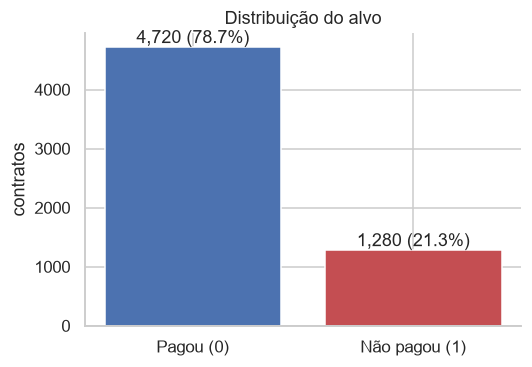

In [3]:
prop = df['inadimplente'].value_counts().sort_index()
taxa = df['inadimplente'].mean()
print(f'Inadimplentes: {prop[1]} de {len(df)} ({taxa:.1%}) | adimplentes: {prop[0]} ({1-taxa:.1%})')

fig, ax = plt.subplots(figsize=(5, 3.5))
barras = ax.bar(['Pagou (0)', 'Não pagou (1)'], prop.values, color=['#4C72B0', '#C44E52'])
ax.bar_label(barras, labels=[f'{v:,} ({v/len(df):.1%})' for v in prop.values])
ax.set_title('Distribuição do alvo'); ax.set_ylabel('contratos')
fig.tight_layout(); fig.savefig(FIG / '01_alvo.png'); plt.show()

A base é **desbalanceada**: cerca de 1 inadimplente para cada 4 adimplentes. Isso tem duas consequências. A acurácia sozinha engana, porque um modelo que aprova todo mundo já acerta cerca de 79%. E a separação treino/teste e os folds precisam ser **estratificados**.

### 1.2 Valores ausentes

,ausentes,%
renda_mensal,363,6.0500
tempo_emprego_anos,470,7.8333


renda_mensal: inadimplência com dado = 21.3% | sem dado = 22.0%
tempo_emprego_anos: inadimplência com dado = 21.4% | sem dado = 20.4%


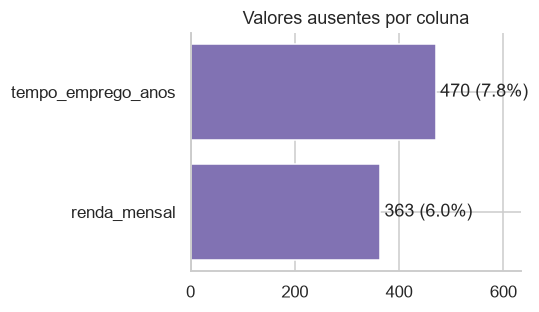

In [4]:
aus = df.isna().sum().to_frame('ausentes')
aus['%'] = aus['ausentes'] / len(df) * 100
aus = aus[aus['ausentes'] > 0]
display(aus)

# ausência é informativa? compara a taxa de inadimplência de quem tem e não tem o dado
for col in aus.index:
    t = df.groupby(df[col].isna())['inadimplente'].mean()
    print(f'{col}: inadimplência com dado = {t[False]:.1%} | sem dado = {t[True]:.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(aus.index, aus['ausentes'], color='#8172B3')
ax.bar_label(ax.containers[0], labels=[f'{n} ({p:.1f}%)' for n, p in zip(aus['ausentes'], aus['%'])], padding=3)
ax.set_title('Valores ausentes por coluna'); ax.set_xlim(0, aus['ausentes'].max() * 1.35)
fig.tight_layout(); fig.savefig(FIG / '02_ausentes.png'); plt.show()

Só duas colunas têm ausentes: **`renda_mensal`** e **`tempo_emprego_anos`**. A taxa de inadimplência é parecida com e sem o dado, o que indica ausência aleatória, e por isso não criamos um indicador de ausência. Os ausentes serão tratados com **imputação pela mediana dentro do Pipeline**. Assim, a mediana é calculada só com os dados de treino de cada fold, sem vazamento. Descartar essas linhas jogaria fora ~13% da base, e o sistema precisa aceitar pedidos sem renda ou tempo de emprego informados.

### 1.3 Inadimplência × score de crédito

,mean,size
score_credito,,
"(299, 400]",0.6703,185
"(400, 500]",0.4935,616
"(500, 600]",0.2818,1398
"(600, 700]",0.1743,1784
"(700, 800]",0.0842,1330
"(800, 900]",0.0593,540
"(900, 1000]",0.0204,147


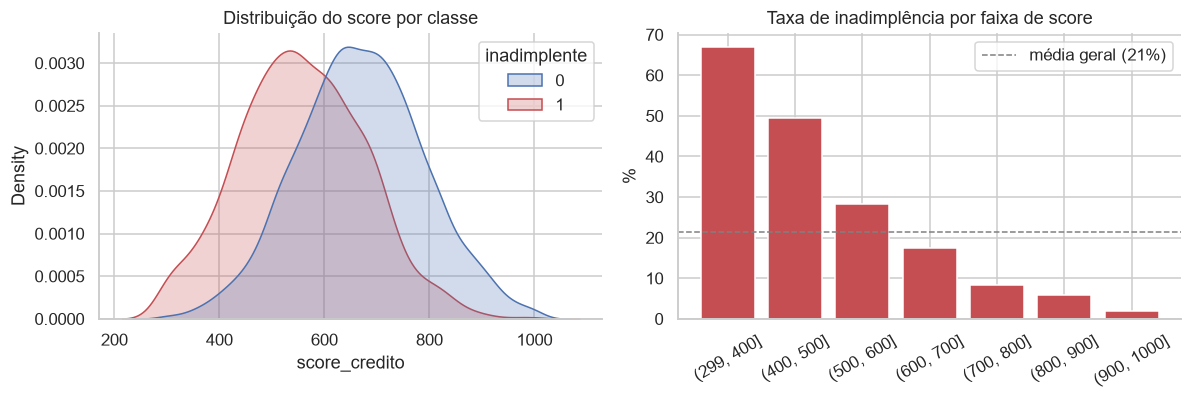

In [5]:
faixas = pd.cut(df['score_credito'], [299, 400, 500, 600, 700, 800, 900, 1000])
por_faixa = df.groupby(faixas, observed=True)['inadimplente'].agg(['mean', 'size'])
display(por_faixa)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
sns.kdeplot(data=df, x='score_credito', hue='inadimplente', common_norm=False, fill=True,
            palette={0: '#4C72B0', 1: '#C44E52'}, ax=axs[0])
axs[0].set_title('Distribuição do score por classe')
axs[1].bar([str(i) for i in por_faixa.index], por_faixa['mean'] * 100, color='#C44E52')
axs[1].axhline(taxa * 100, ls='--', c='gray', lw=1, label=f'média geral ({taxa:.0%})')
axs[1].set_title('Taxa de inadimplência por faixa de score'); axs[1].set_ylabel('%'); axs[1].legend()
axs[1].tick_params(axis='x', rotation=30)
fig.tight_layout(); fig.savefig(FIG / '03_score.png'); plt.show()

### 1.4 Inadimplência × finalidade e posse de imóvel

,taxa,contratos
finalidade,,
negocio,0.3036,863
pessoal,0.2248,2086
reforma,0.1975,896
educacao,0.1882,595
veiculo,0.1667,1560


,taxa,contratos
possui_imovel,,
nao,0.2484,3321
sim,0.1698,2679


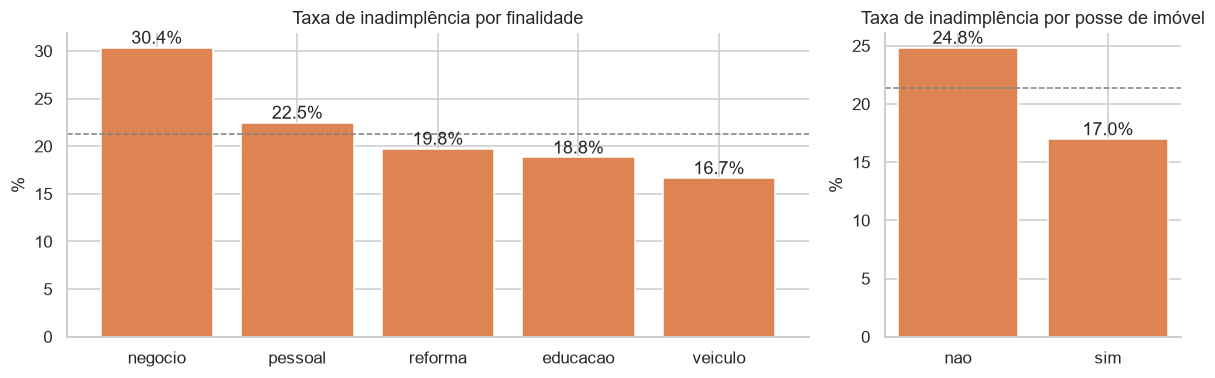

In [6]:
def taxa_por(col):
    return df.groupby(col)['inadimplente'].agg(taxa='mean', contratos='size').sort_values('taxa', ascending=False)

fin, imo = taxa_por('finalidade'), taxa_por('possui_imovel')
display(fin, imo)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios': [5, 2]})
for ax, t, titulo in [(axs[0], fin, 'por finalidade'), (axs[1], imo, 'por posse de imóvel')]:
    b = ax.bar(t.index, t['taxa'] * 100, color='#DD8452')
    ax.bar_label(b, labels=[f'{v:.1%}' for v in t['taxa']])
    ax.axhline(taxa * 100, ls='--', c='gray', lw=1)
    ax.set_title(f'Taxa de inadimplência {titulo}'); ax.set_ylabel('%')
fig.tight_layout(); fig.savefig(FIG / '04_finalidade_imovel.png'); plt.show()

### 1.5 Demais variáveis e correlações

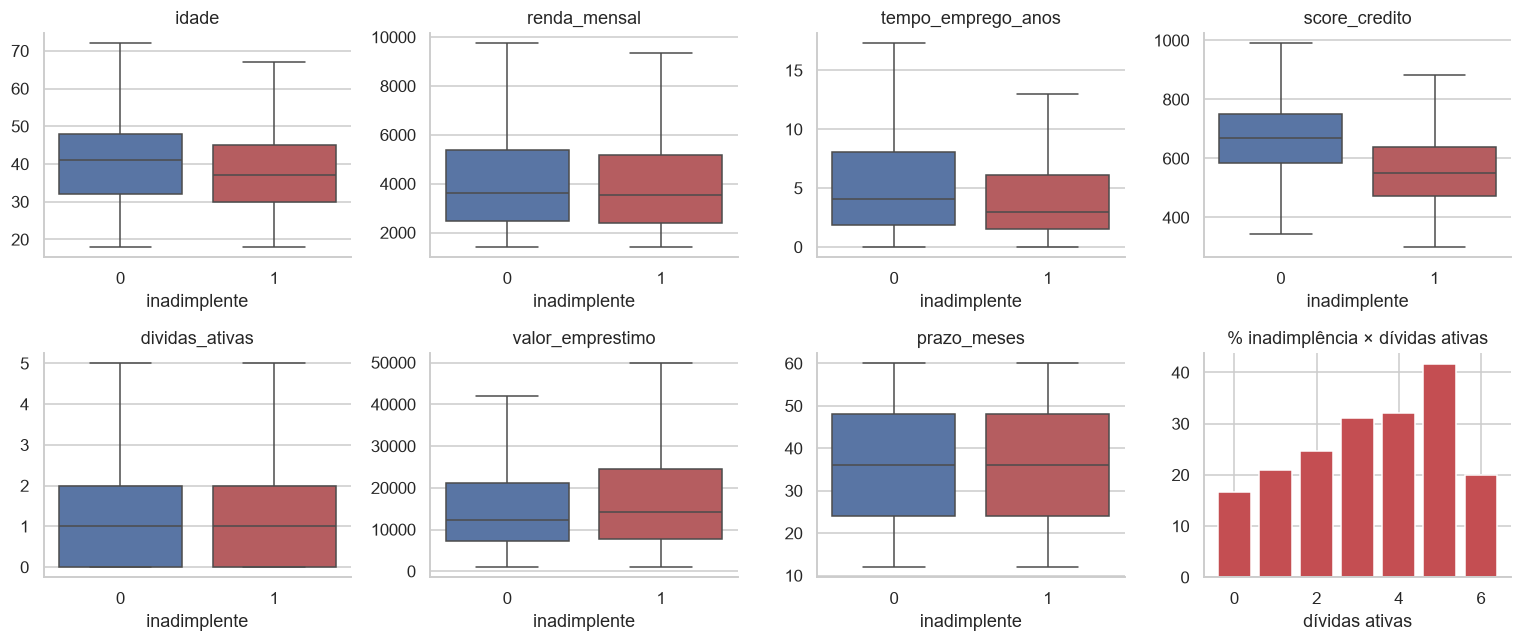

,correlação com inadimplente
score_credito,-0.3547
tempo_emprego_anos,-0.1030
idade,-0.1006
prazo_meses,-0.0570
id_contrato,-0.0280
renda_mensal,-0.0275
valor_emprestimo,0.0692
dividas_ativas,0.1098


In [7]:
num = ['idade', 'renda_mensal', 'tempo_emprego_anos', 'score_credito', 'dividas_ativas',
       'valor_emprestimo', 'prazo_meses']
fig, axs = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axs.flat, num):
    sns.boxplot(data=df, x='inadimplente', y=c, ax=ax, hue='inadimplente', legend=False,
                palette={0: '#4C72B0', 1: '#C44E52'}, showfliers=False)
    ax.set_title(c); ax.set_ylabel('')
t = df.groupby('dividas_ativas')['inadimplente'].mean() * 100
axs.flat[-1].bar(t.index, t.values, color='#C44E52')
axs.flat[-1].set_title('% inadimplência × dívidas ativas'); axs.flat[-1].set_xlabel('dívidas ativas')
fig.tight_layout(); fig.savefig(FIG / '05_numericas.png'); plt.show()

corr = df.drop(columns=['possui_imovel', 'finalidade']).corr(numeric_only=True)['inadimplente'].drop('inadimplente')
corr.sort_values().to_frame('correlação com inadimplente')

### 1.6 Alguma coluna deve ser descartada?

In [8]:
print('id_contrato único por linha:', df['id_contrato'].is_unique)
print(f"correlação id_contrato × alvo: {df['id_contrato'].corr(df['inadimplente']):+.3f}")

id_contrato único por linha: True
correlação id_contrato × alvo: -0.028


**Conclusões da exploração**

- **Proporção:** ~21% de inadimplentes, então a base é desbalanceada e usaremos ROC AUC, precisão e recall, não só acurácia.
- **Ausentes:** `renda_mensal` (363, ~6%) e `tempo_emprego_anos` (470, ~8%). Vão para imputação por mediana dentro do pipeline.
- **Score:** é o sinal mais forte, com relação monotônica. Abaixo de 500 pontos, cerca de metade dos contratos não é paga. Acima de 800, só ~5%.
- **Finalidade:** *negócio* é a finalidade mais arriscada (~30%) e *veículo* a menos arriscada (~17%). A diferença faz sentido, porque o veículo serve de garantia e a renda de um negócio novo é incerta.
- **Imóvel:** quem tem imóvel inadimple menos (~17% contra ~25%).
- **Dívidas ativas** aumentam o risco de forma consistente. Tempo de emprego mais longo o reduz.
- **Descartar `id_contrato`:** é só um identificador sequencial, único por linha e sem relação causal com o pagamento. Se entrasse no modelo, ele poderia decorar ruído, e no sistema cada pedido novo tem um id nunca visto. **Nenhuma outra coluna é descartada.** Todas estão disponíveis *no momento do pedido*, e não há nenhuma variável posterior à concessão (dias de atraso, parcelas pagas etc.) que vazaria o alvo.

## Parte 2 — Modelagem

Separação 80/20 **estratificada** com `random_state=42`. Todo o pré-processamento fica **dentro do `Pipeline`**: imputação (mediana), padronização e one-hot. Isso garante que, em cada fold da validação cruzada, as estatísticas sejam aprendidas só no pedaço de treino.

In [9]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

ALVO = 'inadimplente'
X = df.drop(columns=[ALVO, 'id_contrato'])
y = df[ALVO]
NUM = ['idade', 'renda_mensal', 'tempo_emprego_anos', 'score_credito', 'dividas_ativas',
       'valor_emprestimo', 'prazo_meses']
CAT = ['possui_imovel', 'finalidade']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f'treino: {len(X_treino)} ({y_treino.mean():.1%} inad.) | teste: {len(X_teste)} ({y_teste.mean():.1%} inad.)')

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
criar_pipeline(algoritmos()['regressao_logistica'], NUM, CAT)

treino: 4800 (21.3% inad.) | teste: 1200 (21.3% inad.)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preproc', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

In [10]:
def comparar(modelos, comprometimento=False, **kw):
    linhas = []
    for nome, modelo in modelos.items():
        r = cross_validate(criar_pipeline(modelo, NUM, CAT, comprometimento), X_treino, y_treino,
                           cv=CV, scoring='roc_auc', n_jobs=-1, **kw)
        linhas.append({'algoritmo': nome, 'ROC AUC média': r['test_score'].mean(),
                       'desvio': r['test_score'].std(), 'min': r['test_score'].min(), 'max': r['test_score'].max()})
    return pd.DataFrame(linhas).set_index('algoritmo').sort_values('ROC AUC média', ascending=False)

tabela_cv = comparar(algoritmos())
tabela_cv

,ROC AUC média,desvio,min,max
algoritmo,,,,
regressao_logistica,0.7905,0.0213,0.7583,0.8151
random_forest,0.7783,0.0230,0.7414,0.8036
gradient_boosting,0.7684,0.0232,0.7343,0.7987


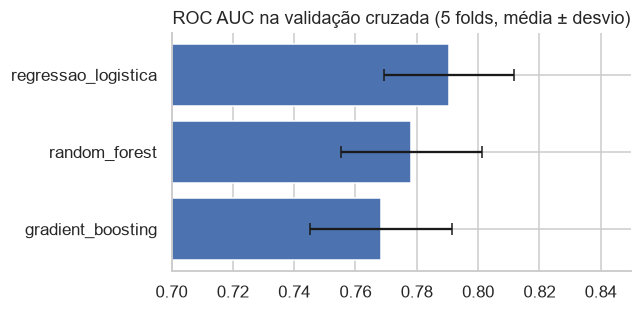

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(tabela_cv.index[::-1], tabela_cv['ROC AUC média'][::-1], xerr=tabela_cv['desvio'][::-1],
        color='#4C72B0', capsize=4)
ax.set_xlim(0.70, 0.85); ax.set_title('ROC AUC na validação cruzada (5 folds, média ± desvio)')
fig.tight_layout(); fig.savefig(FIG / '06_comparacao_cv.png'); plt.show()

A **regressão logística** teve a maior ROC AUC média. A diferença para o Random Forest é pequena (da ordem de um desvio-padrão), e o Gradient Boosting ficou atrás. Faz sentido: as relações são majoritariamente monotônicas (mais score, menos risco; mais dívidas, mais risco), e os modelos de árvore não têm interações fortes para explorar com 4.800 linhas. Também desconfiamos de resultados bons demais: ~0,79 é um valor plausível para crédito, bem longe do alerta de 0,95. Há um ganho prático extra: a logística é **interpretável**, porque cada coeficiente mostra a direção do efeito. Isso ajuda a explicar uma recusa ao cliente, algo exigido pela LGPD (parte 6).

### Desafio extra 1 — feature *comprometimento de renda*

`comprometimento_renda = parcela estimada / renda_mensal`, com parcela pela Tabela Price a 2% a.m. É calculada por um `FunctionTransformer` **dentro do pipeline**. Como é uma conta linha a linha que não aprende nada dos dados, não há vazamento. Quando a renda está ausente, o valor fica ausente e é imputado pela mediana do fold.

In [12]:
tabela_comp = comparar(algoritmos(), comprometimento=True)
efeito = pd.DataFrame({'sem feature': tabela_cv['ROC AUC média'], 'com feature': tabela_comp['ROC AUC média']})
efeito['ganho'] = efeito['com feature'] - efeito['sem feature']
efeito

,sem feature,com feature,ganho
algoritmo,,,
regressao_logistica,0.7905,0.7937,0.0031
random_forest,0.7783,0.7800,0.0017
gradient_boosting,0.7684,0.7667,-0.0017


A feature melhora pouco a logística e o Random Forest (ganho da ordem de milésimos, menor que o desvio entre folds). O motivo é que o modelo já tem renda, valor e prazo e consegue aproximar parte dessa razão. Mesmo assim, a feature **entra no modelo final**: o ganho é consistente, não custa nada e resume em um número a capacidade de pagamento, que é o critério que a equipe de crédito já usa.

### Desafio extra 2 — hiperparâmetros com `GridSearchCV`

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

grades = {
    'regressao_logistica': (LogisticRegression(max_iter=2000),
                            {'modelo__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}),
    'random_forest': (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
                      {'modelo__min_samples_leaf': [5, 10, 20, 40], 'modelo__max_features': ['sqrt', 0.5]}),
}
buscas = {}
for nome, (modelo, grade) in grades.items():
    gs = GridSearchCV(criar_pipeline(modelo, NUM, CAT, comprometimento=True), grade,
                      cv=CV, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_treino, y_treino)
    buscas[nome] = gs
    print(f'{nome}: melhor {gs.best_params_} -> ROC AUC {gs.best_score_:.4f} '
          f'(± {gs.cv_results_["std_test_score"][gs.best_index_]:.4f})')

res_lr = pd.DataFrame(buscas['regressao_logistica'].cv_results_)[['param_modelo__C', 'mean_test_score', 'std_test_score']]
res_lr

regressao_logistica: melhor {'modelo__C': 0.03} -> ROC AUC 0.7944 (± 0.0212)


random_forest: melhor {'modelo__max_features': 0.5, 'modelo__min_samples_leaf': 10} -> ROC AUC 0.7811 (± 0.0234)


,param_modelo__C,mean_test_score,std_test_score
0,0.0100,0.7941,0.0206
1,0.0300,0.7944,0.0212
2,0.1000,0.7940,0.0214
3,0.3000,0.7938,0.0216
4,1.0000,0.7937,0.0216
5,3.0000,0.7937,0.0216
6,10.0000,0.7937,0.0216


A busca confirma a leitura anterior. A regressão logística é pouco sensível a `C` numa faixa ampla, e o melhor valor muda a AUC só na quarta casa. O Random Forest ajustado **não supera** a logística. Por isso o modelo final é a **regressão logística com a feature de comprometimento**. O valor de `C` escolhido pela busca vai para `config.py` (`hiperparametros`).

### Desafio extra 3 — `class_weight='balanced'`

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

C_OTIMO = buscas['regressao_logistica'].best_params_['modelo__C']
linhas = []
for cw in [None, 'balanced']:
    pipe = criar_pipeline(LogisticRegression(max_iter=2000, C=C_OTIMO, class_weight=cw), NUM, CAT, True)
    p = cross_val_predict(pipe, X_treino, y_treino, cv=CV, method='predict_proba')[:, 1]
    pred = (p >= 0.5).astype(int)
    linhas.append({'class_weight': str(cw), 'precisão': precision_score(y_treino, pred),
                   'recall': recall_score(y_treino, pred), 'F1': f1_score(y_treino, pred),
                   'ROC AUC': roc_auc_score(y_treino, p), 'prob. média prevista': p.mean()})
pd.DataFrame(linhas).set_index('class_weight')

,precisão,recall,F1,ROC AUC,prob. média prevista
class_weight,,,,,
None,0.6514,0.2646,0.3764,0.7942,0.2133
balanced,0.4101,0.7197,0.5225,0.7941,0.4273


Com `class_weight='balanced'`, os erros na classe minoritária pesam mais no treino. As probabilidades sobem (a média prevista vai de ~21% para ~43%) e, **com o mesmo limiar de 0,5**, o recall salta de ~0,26 para ~0,72 enquanto a precisão cai de ~0,65 para ~0,41. O F1 melhora. **A ROC AUC praticamente não muda**, porque a ordenação dos clientes continua a mesma. Ou seja, *balancear equivale a deslocar o limiar*. Além disso, o balanceamento estraga a calibração: a probabilidade deixa de ser "chance real de inadimplência". Por isso **mantemos `class_weight=None`** e tratamos o desbalanceamento de forma explícita na parte 4, escolhendo o limiar pelo custo de negócio.

In [15]:
C_OTIMO = buscas['regressao_logistica'].best_params_['modelo__C']
modelo_final = criar_pipeline(LogisticRegression(max_iter=2000, C=C_OTIMO), NUM, CAT, comprometimento=True)
print('Modelo final: regressão logística + comprometimento de renda, C =', C_OTIMO)

Modelo final: regressão logística + comprometimento de renda, C = 0.03


## Parte 3 — Avaliação no conjunto de teste

O modelo escolhido é treinado em todo o treino e avaliado **uma única vez** no teste (1.200 contratos que não participaram de nenhuma escolha). Aqui usamos o limiar padrão de 0,5. O limiar ideal é estudado na parte 4.

In [16]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             roc_curve, RocCurveDisplay)

modelo_final.fit(X_treino, y_treino)
prob_teste = modelo_final.predict_proba(X_teste)[:, 1]
pred_teste = (prob_teste >= 0.5).astype(int)

def metricas(y, pred, prob):
    return {'acurácia': accuracy_score(y, pred), 'precisão': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred), 'F1': f1_score(y, pred), 'ROC AUC': roc_auc_score(y, prob)}

met_teste = pd.Series(metricas(y_teste, pred_teste, prob_teste), name='teste (limiar 0,5)')
display(met_teste.to_frame())
print(f"Referência — ROC AUC na validação cruzada: {buscas['regressao_logistica'].best_score_:.4f}")
print(f'Referência — acurácia de aprovar todo mundo: {1 - y_teste.mean():.4f}')

,"teste (limiar 0,5)"
acurácia,0.8108
precisão,0.6465
recall,0.2500
F1,0.3606
ROC AUC,0.8075


Referência — ROC AUC na validação cruzada: 0.7944
Referência — acurácia de aprovar todo mundo: 0.7867


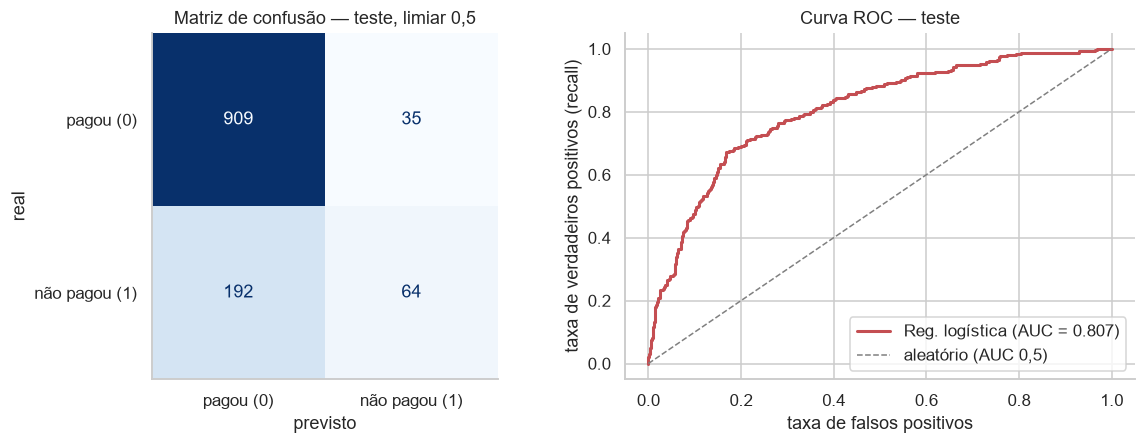

VN=909  FP=35  FN=192  VP=64
Custo no teste com limiar 0,5: R$ 1,588,500


In [17]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
cm = confusion_matrix(y_teste, pred_teste)
ConfusionMatrixDisplay(cm, display_labels=['pagou (0)', 'não pagou (1)']).plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title('Matriz de confusão — teste, limiar 0,5')
axs[0].set_xlabel('previsto'); axs[0].set_ylabel('real'); axs[0].grid(False)

fpr, tpr, _ = roc_curve(y_teste, prob_teste)
axs[1].plot(fpr, tpr, c='#C44E52', lw=2, label=f'Reg. logística (AUC = {roc_auc_score(y_teste, prob_teste):.3f})')
axs[1].set_xlabel('taxa de falsos positivos'); axs[1].set_ylabel('taxa de verdadeiros positivos (recall)')
axs[1].plot([0, 1], [0, 1], ls='--', c='gray', lw=1, label='aleatório (AUC 0,5)')
axs[1].set_title('Curva ROC — teste'); axs[1].legend(loc='lower right')
fig.tight_layout(); fig.savefig(FIG / '07_teste_cm_roc.png'); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'VN={tn}  FP={fp}  FN={fn}  VP={tp}')
print(f'Custo no teste com limiar 0,5: R$ {fn*CUSTO_FN + fp*CUSTO_FP:,.0f}')

**Interpretação no negócio**

- A ROC AUC no teste é compatível com a da validação cruzada. O modelo generaliza e não há sinal de sobreajuste ou vazamento. Na prática, ao sortear um inadimplente e um adimplente, o modelo dá risco maior ao inadimplente em ~4 de cada 5 vezes.
- A acurácia com limiar 0,5 fica pouco acima de "aprovar todo mundo" (~79%). É o reflexo do desbalanceamento. O **recall baixo** mostra que esse limiar deixa passar a maioria dos inadimplentes.

**Falso positivo × falso negativo** (classe positiva = inadimplente):

- **Falso positivo (FP):** o modelo diz "vai dar calote", mas o cliente pagaria. O **bom cliente é recusado**. A fintech perde o lucro do contrato (R$ 1.500), o cliente vai para a concorrência e a experiência dele piora.
- **Falso negativo (FN):** o modelo diz "vai pagar", mas o cliente não paga. O **empréstimo é concedido a um inadimplente**. A fintech perde o capital emprestado e ainda paga custos de cobrança (R$ 8.000).

O **falso negativo é bem mais caro**: cada um custa o mesmo que ~5,3 falsos positivos. Então vale recusar alguns bons clientes a mais para barrar inadimplentes, e o limiar ótimo deve ficar **bem abaixo de 0,5**.

## Parte 4 — Limiar de decisão por custo

As probabilidades para escolher o limiar vêm de `cross_val_predict` **no treino**: cada contrato recebe a probabilidade de um modelo que não o viu. O teste não participa da escolha.

In [18]:
prob_oof = cross_val_predict(modelo_final, X_treino, y_treino, cv=5, method='predict_proba')[:, 1]

def tabela_limiares(y, prob, limiares):
    linhas = []
    for t in limiares:
        pred = (prob >= t).astype(int)
        custo, fn, fp = custo_total(y, prob, t, CUSTO_FN, CUSTO_FP)
        linhas.append({'limiar': t, 'precisão': precision_score(y, pred, zero_division=0),
                       'recall': recall_score(y, pred), 'aprovados (%)': (pred == 0).mean() * 100,
                       'FN (inad. aprovados)': fn, 'FP (bons recusados)': fp, 'custo total (R$)': custo})
    return pd.DataFrame(linhas).set_index('limiar')

LIMIARES = [0.10, 0.15, 0.20, 0.21, 0.25, 0.30, 0.40, 0.50]
tab_lim = tabela_limiares(y_treino, prob_oof, LIMIARES)
tab_lim.style.format({'precisão': '{:.3f}', 'recall': '{:.3f}', 'aprovados (%)': '{:.1f}',
                      'custo total (R$)': 'R$ {:,.0f}'}).highlight_min(subset='custo total (R$)', color='#c6efce')

,precisão,recall,aprovados (%),FN (inad. aprovados),FP (bons recusados),custo total (R$)
limiar,,,,,,
0.100000,0.289,0.913,32.5,89,2304,"R$ 4,168,000"
0.150000,0.340,0.834,47.7,170,1655,"R$ 3,842,500"
0.200000,0.393,0.755,59.0,251,1193,"R$ 3,797,500"
0.210000,0.405,0.744,60.8,262,1118,"R$ 3,773,000"
0.250000,0.455,0.676,68.3,332,829,"R$ 3,899,500"
0.300000,0.497,0.586,74.9,424,607,"R$ 4,302,500"
0.400000,0.599,0.439,84.4,574,301,"R$ 5,043,500"
0.500000,0.672,0.274,91.3,743,137,"R$ 6,149,500"


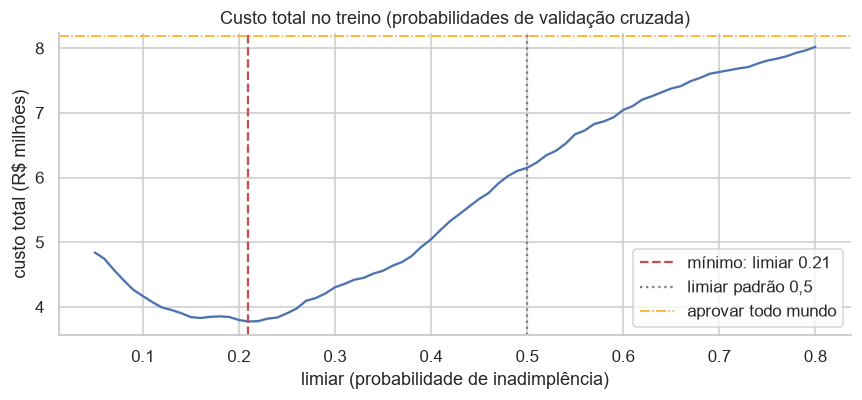

Limiar de menor custo (treino, CV): 0.21 -> R$ 3,773,000


In [19]:
grade = np.round(np.arange(0.05, 0.81, 0.01), 2)
custos = np.array([custo_total(y_treino, prob_oof, t, CUSTO_FN, CUSTO_FP)[0] for t in grade])
LIMIAR = melhor_limiar(y_treino, prob_oof, CUSTO_FN, CUSTO_FP)
custo_aprova_todos = y_treino.sum() * CUSTO_FN

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(grade, custos / 1e6, c='#4C72B0')
ax.axvline(LIMIAR, c='#C44E52', ls='--', label=f'mínimo: limiar {LIMIAR:.2f}')
ax.axvline(0.5, c='gray', ls=':', label='limiar padrão 0,5')
ax.axhline(custo_aprova_todos / 1e6, c='orange', ls='-.', lw=1, label='aprovar todo mundo')
ax.set_xlabel('limiar (probabilidade de inadimplência)'); ax.set_ylabel('custo total (R$ milhões)')
ax.set_title('Custo total no treino (probabilidades de validação cruzada)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / '08_custo_limiar.png'); plt.show()
print(f'Limiar de menor custo (treino, CV): {LIMIAR:.2f} -> R$ {custos.min():,.0f}')

### Custo do limiar recomendado no conjunto de teste

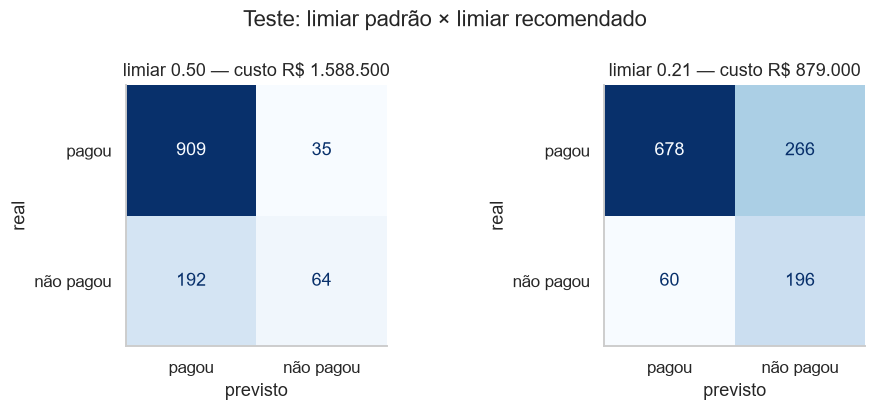

,precisão,recall,aprovados (%),FN,FP,custo (R$),economia vs aprovar todos (R$)
política,,,,,,,
aprovar todo mundo,0.000,0.000,100.0,256,0,"R$ 2,048,000",R$ 0
"limiar padrão 0,5",0.646,0.250,91.8,192,35,"R$ 1,588,500","R$ 459,500"
limiar recomendado 0.21,0.424,0.766,61.5,60,266,"R$ 879,000","R$ 1,169,000"


In [20]:
comparacao = []
for nome, t in [('aprovar todo mundo', 1.01), ('limiar padrão 0,5', 0.5), (f'limiar recomendado {LIMIAR:.2f}', LIMIAR)]:
    custo, fn, fp = custo_total(y_teste, prob_teste, t, CUSTO_FN, CUSTO_FP)
    pred = (prob_teste >= t).astype(int)
    comparacao.append({'política': nome, 'precisão': precision_score(y_teste, pred, zero_division=0),
                       'recall': recall_score(y_teste, pred), 'aprovados (%)': (pred == 0).mean() * 100,
                       'FN': fn, 'FP': fp, 'custo (R$)': custo})
comparacao = pd.DataFrame(comparacao).set_index('política')
comparacao['economia vs aprovar todos (R$)'] = comparacao['custo (R$)'].iloc[0] - comparacao['custo (R$)']

fig, axs = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, t in zip(axs, [0.5, LIMIAR]):
    ConfusionMatrixDisplay(confusion_matrix(y_teste, (prob_teste >= t).astype(int)),
                           display_labels=['pagou', 'não pagou']).plot(ax=ax, cmap='Blues', colorbar=False)
    c = custo_total(y_teste, prob_teste, t, CUSTO_FN, CUSTO_FP)[0]
    ax.set_title(f'limiar {t:.2f} — custo R$ {c:,.0f}'.replace(',', '.')); ax.grid(False)
    ax.set_xlabel('previsto'); ax.set_ylabel('real')
fig.suptitle('Teste: limiar padrão × limiar recomendado'); fig.tight_layout()
fig.savefig(FIG / '10_teste_limiares.png'); plt.show()
comparacao.style.format({'precisão': '{:.3f}', 'recall': '{:.3f}', 'aprovados (%)': '{:.1f}',
                         'custo (R$)': 'R$ {:,.0f}', 'economia vs aprovar todos (R$)': 'R$ {:,.0f}'})

**Recomendação: limiar de 0,21.** Um pedido com probabilidade de inadimplência ≥ 21% é marcado como **risco alto** e vai para recusa ou análise manual. Os demais são aprovados.

| política (conjunto de teste, 1.200 contratos) | recall | precisão | aprovados | custo |
|---|---|---|---|---|
| aprovar todo mundo | 0,00 | — | 100% | R$ 2.048.000 |
| limiar padrão 0,5 | 0,25 | 0,65 | 92% | R$ 1.588.500 |
| **limiar recomendado 0,21** | **0,77** | **0,42** | **61%** | **R$ 879.000** |

Justificativa:
1. **Menor custo sem olhar o teste.** 0,21 minimiza o custo total nas probabilidades de validação cruzada do treino (R$ 3,77 mi em 4.800 contratos, contra R$ 6,15 mi com 0,5). No teste, o custo é **R$ 879 mil**: 45% menor que com o limiar 0,5 e 57% menor que aprovar todo mundo. O resultado se confirmou em dados novos.
2. **Coerência com a teoria.** Com FN = R$ 8.000 e FP = R$ 1.500, recusar compensa quando *p × 8.000 > (1 − p) × 1.500*, ou seja, *p > 1.500 / 9.500 ≈ 0,16*. O ótimo empírico (0,21) fica perto disso.
3. **Estabilidade.** A curva de custo é achatada entre ~0,15 e ~0,22 (diferenças abaixo de 2%). Qualquer valor nessa faixa é defensável. Isso dá à equipe de crédito margem para ajustar o volume de aprovações sem grande impacto no prejuízo.

O preço é recusar mais gente, e o percentual de aprovados cai. Se a fintech tiver meta de volume, dá para subir o limiar aceitando um custo maior. A tabela de limiares mostra essa troca. O limiar também é recalculado automaticamente por `treinar.py` e usado pelo sistema.

### Quais variáveis pesam no modelo?

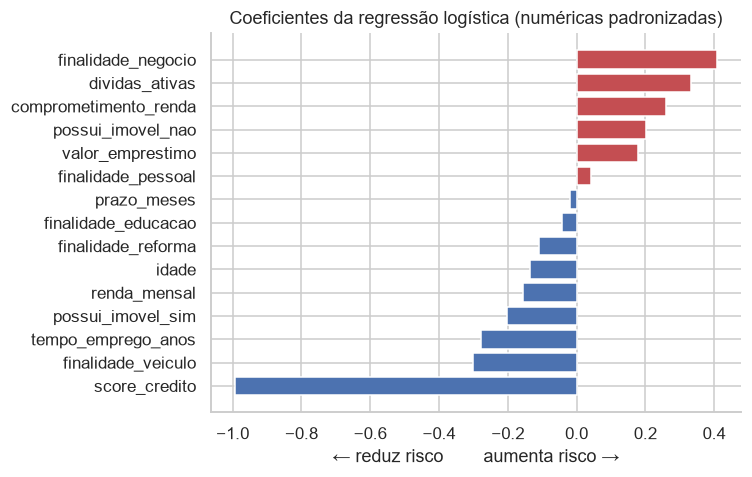

In [21]:
lr = modelo_final.named_steps['modelo']
nomes = modelo_final.named_steps['preproc'].get_feature_names_out()
coef = pd.Series(lr.coef_[0], index=[n.split('__')[1] for n in nomes]).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(coef.index, coef.values, color=np.where(coef > 0, '#C44E52', '#4C72B0'))
ax.set_title('Coeficientes da regressão logística (numéricas padronizadas)')
ax.set_xlabel('← reduz risco        aumenta risco →')
fig.tight_layout(); fig.savefig(FIG / '09_coeficientes.png'); plt.show()

Os sinais batem com a exploração. **Score** é o principal redutor de risco. **Dívidas ativas** e **comprometimento de renda** aumentam o risco. Ter imóvel e mais tempo de emprego o reduzem. *Negócio* e *pessoal* são as finalidades mais arriscadas.

## Parte 6 — Reflexão ética

Modelos de crédito decidem o acesso das pessoas a dinheiro, e por isso podem **reproduzir e ampliar desigualdades históricas**. Se o histórico usado no treino reflete décadas de exclusão de certos grupos, o modelo aprende que esses grupos são "arriscados" e perpetua o ciclo, mesmo sem ver o atributo sensível, por meio de **variáveis proxy**. Um exemplo é o CEP, que funciona como proxy de raça e classe social. Mesmo que melhorassem a ROC AUC, eu **não usaria** sexo, raça/cor, religião, orientação sexual, estado civil, deficiência, nacionalidade, CEP ou bairro, nem dados de redes sociais ou de navegação. **Usaria com cautela a `idade` deste modelo**: é legítima em parte (ciclo de vida da renda), mas pode penalizar jovens e idosos. O ideal é auditar o desempenho e a taxa de aprovação por faixa etária e considerar retirá-la. A **LGPD** (Lei 13.709/2018) se aplica diretamente. O tratamento tem base legal na proteção do crédito (art. 7º, X) e na execução de contrato, mas deve seguir os princípios de **finalidade, necessidade e não discriminação** (art. 6º), ou seja, coletar só o necessário e nunca usar dados para fins discriminatórios ilícitos ou abusivos. Dados sensíveis (art. 11) exigem proteção reforçada. O **art. 20** garante ao titular o direito de pedir **revisão de decisões tomadas unicamente por tratamento automatizado** e de receber informações claras sobre os critérios usados. Por isso é importante um modelo interpretável como a regressão logística, com revisão humana nos casos de risco alto. Também é preciso segurança dos dados, retenção limitada, um relatório de impacto (RIPD) e monitoramento contínuo de vieses e de *drift*.